## Ансамбли и полносвязные нейронные сети
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.76$ - 0 баллов
- $0.76 < AUC \leq 0.77$ - 2 балла
- $0.77 < AUC \leq 0.78$ - 4 балла
- $0.78 < AUC \leq 0.79$ - 6 баллов
- $0.79 < AUC \leq 0.80$ - 8 баллов
- $AUC > 0.80$ - 10 баллов


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


In [8]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())
print(f"Размер данных: {data.shape}")
print("Распределение классов:")
print(data['Creditability'].value_counts(normalize=True).sort_index().round(3))
print(f"Пропусков: {data.isna().sum().sum()}")

X = data.drop(columns='Creditability')
y = data['Creditability']

numeric_features = ['Duration_of_Credit_monthly', 'Credit_Amount', 'Age_years']
categorical_features = [column for column in X.columns if column not in numeric_features]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)


   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

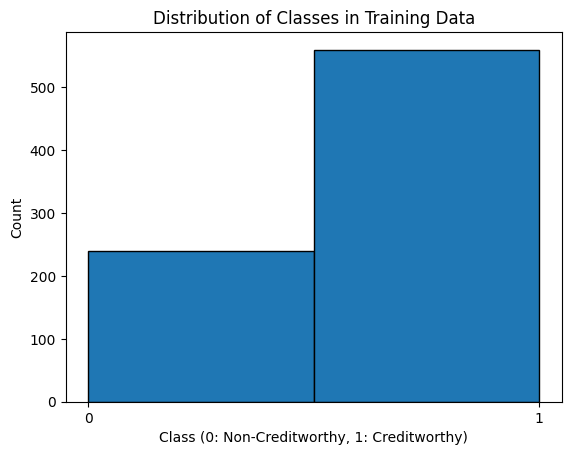

In [9]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()


In [10]:
def score_model(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        'model': name,
        'roc_auc': roc_auc_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
    }

baseline_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'MLP': MLPClassifier(hidden_layer_sizes=(30,), max_iter=500, random_state=RANDOM_STATE),
}

baseline_results = []
for name, estimator in baseline_models.items():
    model = Pipeline([('preprocess', preprocessor), ('model', estimator)])
    baseline_results.append(score_model(name, model))

baseline_results = pd.DataFrame(baseline_results).sort_values('roc_auc', ascending=False)
print('Baseline модели:')
display(baseline_results.round(4))


Baseline модели:


,model,roc_auc,accuracy,precision,recall
0,Random Forest,0.8303,0.785,0.7904,0.9429
1,Gradient Boosting,0.8183,0.770,0.8052,0.8857
2,MLP,0.7810,0.755,0.8227,0.8286


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

experiments = {
    'Random Forest': (
        RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
        {
            'model__n_estimators': [300, 500],
            'model__max_depth': [6, 8, None],
            'model__min_samples_leaf': [3, 5, 10],
            'model__max_features': ['sqrt', 0.5],
        },
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {
            'model__n_estimators': [120, 160],
            'model__learning_rate': [0.03, 0.05, 0.08],
            'model__max_depth': [2, 3],
            'model__subsample': [0.9, 1.0],
        },
    ),
    'MLP': (
        MLPClassifier(max_iter=1200, early_stopping=True, random_state=RANDOM_STATE),
        {
            'model__hidden_layer_sizes': [(16,), (32,), (32, 16)],
            'model__alpha': [0.01, 0.1],
            'model__learning_rate_init': [0.001, 0.003],
        },
    ),
}

results = []
best_models = {}

for name, (estimator, params) in experiments.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', estimator)])
    search = GridSearchCV(pipe, params, scoring='roc_auc', cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)

    best_models[name] = search.best_estimator_
    pred = search.predict(X_test)
    proba = search.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'cv_roc_auc': search.best_score_,
        'test_roc_auc': roc_auc_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'best_params': search.best_params_,
    })

results = pd.DataFrame(results).sort_values('test_roc_auc', ascending=False)
print('Результаты после подбора параметров:')
display(results.round(4))


Результаты после подбора параметров:


,model,cv_roc_auc,test_roc_auc,accuracy,precision,recall,best_params
0,Random Forest,0.7783,0.8343,0.765,0.8444,0.8143,"{'model__max_depth': None, 'model__max_feature..."
1,Gradient Boosting,0.7787,0.8313,0.785,0.8089,0.9071,"{'model__learning_rate': 0.05, 'model__max_dep..."
2,MLP,0.7666,0.8049,0.795,0.8322,0.8857,"{'model__alpha': 0.1, 'model__hidden_layer_siz..."


In [12]:
best = results.iloc[0]
print(f"Лучшая модель: {best['model']}")
print(f"ROC-AUC на тесте: {best['test_roc_auc']:.4f}")
print("Лучшие параметры:")
for key, value in best['best_params'].items():
    print(f"{key}: {value}")


Лучшая модель: Random Forest
ROC-AUC на тесте: 0.8343
Лучшие параметры:
model__max_depth: None
model__max_features: sqrt
model__min_samples_leaf: 5
model__n_estimators: 300
